In [2]:
import yfinance as yf

stk_data = yf.download("ITC.NS",
                       start="2021-06-01",
                       end="2026-01-19")

# Remove MultiIndex if present
if isinstance(stk_data.columns, tuple) or hasattr(stk_data.columns, 'levels'):
    stk_data.columns = stk_data.columns.get_level_values(0)

stk_data = stk_data[['Open', 'High', 'Low', 'Close', 'Volume']]

print(stk_data.head())

[*********************100%***********************]  1 of 1 completed

Price             Open        High         Low       Close     Volume
Date                                                                 
2021-06-01  171.372448  172.473006  168.424528  169.210632   40247686
2021-06-02  165.476600  167.009519  163.982983  164.297424  100377464
2021-06-03  165.673115  165.673115  164.061579  164.336731   48454441
2021-06-04  164.690488  164.847709  163.511325  164.100906   31286264
2021-06-07  165.397985  166.970206  165.240764  166.223404   32643869


In [3]:
column="Close"

In [4]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (1148, 1)


In [5]:
len(data1)

1148

In [6]:
training_size = round(len(data1 ) * 0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

918
X_train length: (918, 1)
X_test length: (230, 1)
y_train length: (918, 1)
y_test length: (230, 1)


In [16]:
from sklearn.metrics import mean_squared_error
import pandas as pd
trends=['n','t','c','ct']
lags=[1,2,3,4]
from statsmodels.tsa.ar_model import AutoReg
results=[]
for i in lags:
    #print(i)
   
    for td in trends:
        try:
        
            #print(td)
            #trendslist.append(td)
            model = AutoReg(X_train, lags=i,trend=td)
            model_fit = model.fit()
            # make prediction
            y_pred= model_fit.predict(len(X_train), len(data1)-1)
            #print(y_pred)
            #mse=mean_squared_error(y_test,y_pred,squared=False)
            from stockFunctions import rmsemape
            print("Lag={},Trend={}".format(i,td))
            rmsemape(y_test,y_pred)
            print("************")
            results.append({
                "Lag": lag,
                "Trend": trend,
                "AIC": model_fit.aic,
                "BIC": model_fit.bic,
                "RMSE": rmse
            })

        except:
            continue

results_df = pd.DataFrame(results)

# Sort by AIC
best_model = results_df.sort_values("AIC").iloc[0]

print("Best Model Based on AIC")
print(best_model)

results_df.sort_values("AIC").head()

Lag=1,Trend=n
RMSE-Testset: 0.09153343034316785
MAPE-Testset: 8.98990175103851
************
Lag=1,Trend=t
RMSE-Testset: 0.27360747773347216
MAPE-Testset: 31.848933299093208
************
Lag=1,Trend=c
RMSE-Testset: 0.07068559934160347
MAPE-Testset: 6.591311393411489
************
Lag=1,Trend=ct
RMSE-Testset: 0.18382218171642412
MAPE-Testset: 20.519446663635584
************
Lag=2,Trend=n
RMSE-Testset: 0.0937071761999449
MAPE-Testset: 9.254411723050893
************
Lag=2,Trend=t
RMSE-Testset: 0.2670227840399859
MAPE-Testset: 30.957335230249623
************
Lag=2,Trend=c
RMSE-Testset: 0.07172269820989767
MAPE-Testset: 6.721051985167668
************
Lag=2,Trend=ct
RMSE-Testset: 0.16588963058453857
MAPE-Testset: 18.228658618756388
************
Lag=3,Trend=n
RMSE-Testset: 0.0936731491671856
MAPE-Testset: 9.25024042037817
************
Lag=3,Trend=t
RMSE-Testset: 0.26790042320369994
MAPE-Testset: 31.07407561110974
************
Lag=3,Trend=c
RMSE-Testset: 0.0717646011919325
MAPE-Testset: 6.726895

,Lag,Trend,AIC,BIC,RMSE
2,5,ct,-5376.286011,-5361.822689,0.183029
3,5,ct,-5374.990041,-5355.705611,0.183029
1,5,ct,-5374.351883,-5359.888561,0.183029
0,5,ct,-5373.947451,-5364.305236,0.183029
6,5,ct,-5370.321824,-5351.041759,0.183029


In [34]:
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, r2_score
from stockFunctions import rmsemape

i = 4


td = 'c'

# Build model
model = AutoReg(X_train, lags=i, trend=td)
model_fit = model.fit()

# Correct prediction range
y_pred = model_fit.predict(start=len(X_train),
                           end=len(X_train) + len(y_test) - 1)

# Calculate RMSE safely (works in all sklearn versions)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R2 Score
r2 = r2_score(y_test, y_pred)

print(f"Lag={i}, Trend={td}")
print("RMSE:", rmse)
print("R2:", r2)

# Custom metrics
rmsemape(y_test, y_pred)

print("************")

Lag=4, Trend=c
RMSE: 0.06821360869750705
R2: -0.5057232846478792
RMSE-Testset: 0.06821360869750705
MAPE-Testset: 6.286777070329268
************


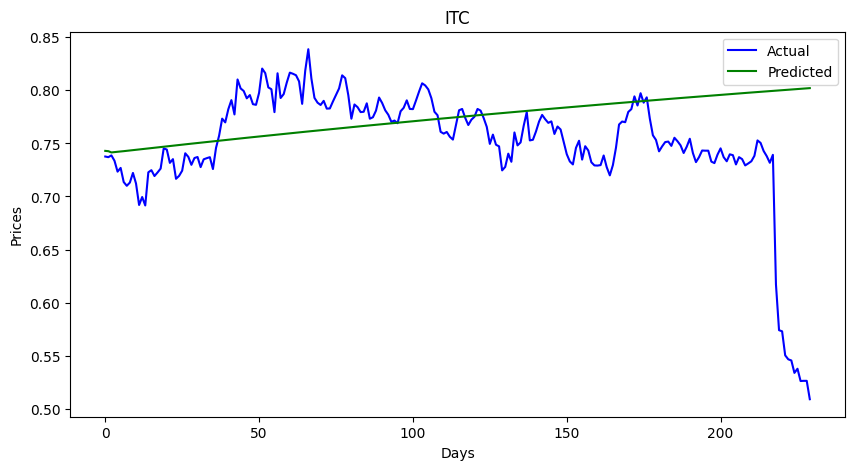

In [35]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","ITC","Days","Prices")

In [36]:
len(data1)

1148

In [37]:
y_test

array([[0.7376284 ],
       [0.73701577],
       [0.73870063],
       [0.73364585],
       [0.72338278],
       [0.72690591],
       [0.71357932],
       [0.7100561 ],
       [0.71311981],
       [0.72215733],
       [0.71220067],
       [0.69198104],
       [0.69948691],
       [0.69152152],
       [0.72276996],
       [0.72476143],
       [0.71924693],
       [0.72261685],
       [0.72629318],
       [0.74528737],
       [0.74421504],
       [0.73165448],
       [0.73517751],
       [0.71664284],
       [0.71940013],
       [0.72430181],
       [0.74069201],
       [0.73732199],
       [0.72981631],
       [0.73624984],
       [0.73716888],
       [0.72767183],
       [0.7350243 ],
       [0.73609654],
       [0.73701577],
       [0.72583357],
       [0.74574689],
       [0.75723531],
       [0.77331899],
       [0.76979596],
       [0.78220351],
       [0.79078152],
       [0.77730183],
       [0.81023533],
       [0.80181042],
       [0.79935944],
       [0.79246648],
       [0.795

In [38]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])

In [39]:
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)

In [40]:
actual_stock_price_test_ori

array([[394.222229  ],
       [394.02990723],
       [394.55883789],
       [392.97198486],
       [389.75009155],
       [390.85610962],
       [386.67248535],
       [385.56643677],
       [386.52822876],
       [389.36538696],
       [386.23968506],
       [379.89212036],
       [382.2484436 ],
       [379.74786377],
       [389.55770874],
       [390.18289185],
       [388.45172119],
       [389.50964355],
       [390.66375732],
       [396.62661743],
       [396.28997803],
       [392.34683228],
       [393.45281982],
       [387.63421631],
       [388.49981689],
       [390.03860474],
       [395.18399048],
       [394.1260376 ],
       [391.76977539],
       [393.78945923],
       [394.07797241],
       [391.09655762],
       [393.40472412],
       [393.74133301],
       [394.02990723],
       [390.51947021],
       [396.77087402],
       [400.37744141],
       [405.42660522],
       [404.32061768],
       [408.21572876],
       [410.90863037],
       [406.67694092],
       [417

In [41]:
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [42]:
actual_stock_price_test_oriA

,Close
0,394.222229
1,394.029907
2,394.558838
3,392.971985
4,389.750092
...,...
225,331.453522
226,327.829498
227,327.878448
228,327.878448


In [43]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [44]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

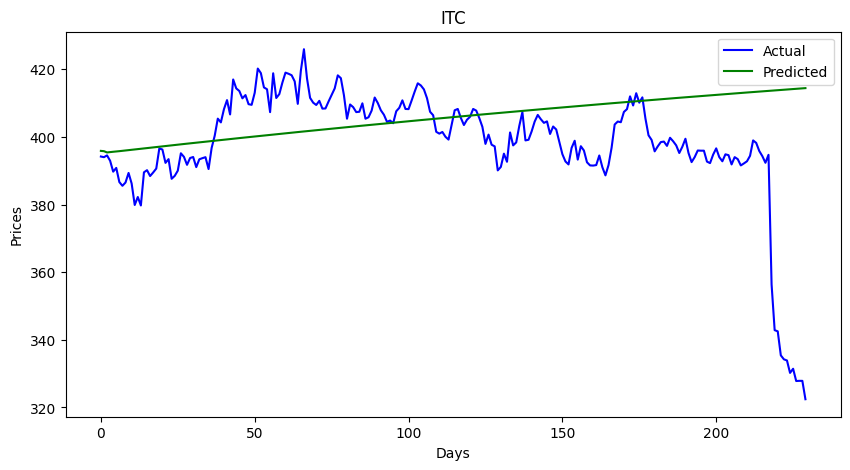

In [45]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","ITC","Days","Prices")

In [46]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 21.414349721650307
MAPE-Testset: 3.52990676344497


In [53]:
forecast=model_fit.predict(len(data1), len(data1)+60)

In [54]:
forecast

array([0.80228738, 0.80249969, 0.8027116 , 0.80292309, 0.80313418,
       0.80334485, 0.80355512, 0.80376499, 0.80397444, 0.80418349,
       0.80439214, 0.80460038, 0.80480822, 0.80501566, 0.80522269,
       0.80542933, 0.80563556, 0.8058414 , 0.80604684, 0.80625188,
       0.80645652, 0.80666077, 0.80686462, 0.80706808, 0.80727114,
       0.80747381, 0.80767609, 0.80787798, 0.80807947, 0.80828058,
       0.80848129, 0.80868162, 0.80888156, 0.80908112, 0.80928028,
       0.80947907, 0.80967746, 0.80987548, 0.81007311, 0.81027035,
       0.81046722, 0.81066371, 0.81085981, 0.81105553, 0.81125088,
       0.81144585, 0.81164044, 0.81183465, 0.81202849, 0.81222196,
       0.81241504, 0.81260776, 0.8128001 , 0.81299207, 0.81318367,
       0.8133749 , 0.81356575, 0.81375624, 0.81394636, 0.81413611,
       0.8143255 ])

In [55]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [56]:
forecast_stock_price_test_oriF

,Closefore
0,414.520671
1,414.587324
2,414.653848
3,414.720242
4,414.786509
...,...
56,418.061301
57,418.121101
58,418.180786
59,418.240354


In [57]:
forecast_stock_price_test_oriF.to_csv("CloseAR.csv",index=False)

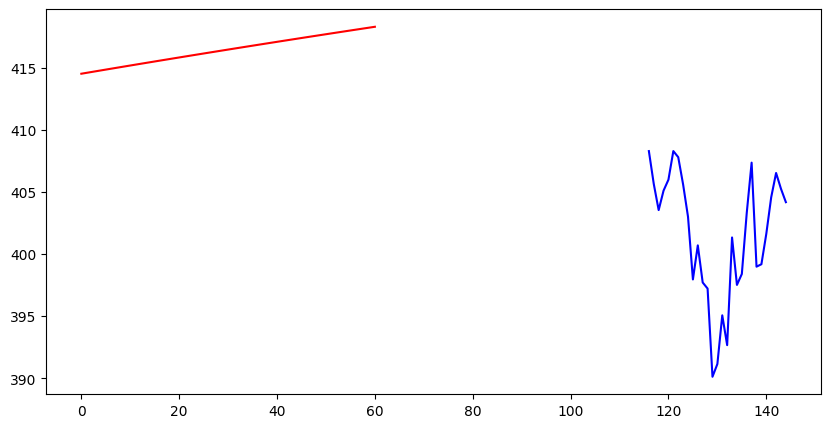

In [58]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[116:145], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")